In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

from sklearn.base import clone
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, roc_auc_score
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor

from Model_pipeline import TwoStagePipeline

In [2]:
def safe_spearman(y_true, y_pred):
    corr = spearmanr(y_true, y_pred).correlation
    return 0.0 if pd.isna(corr) else corr


def evaluate_two_stage_model(clf, reg, X_val, y_class_val, y_reg_val, threshold_grid=None):
    if threshold_grid is None:
        threshold_grid = np.arange(0.40, 0.61, 0.01)

    proba_val = clf.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_class_val, proba_val)

    reg_pred_log = reg.predict(X_val)
    reg_pred = np.expm1(reg_pred_log)
    reg_pred = np.clip(reg_pred, 0, None)

    pred_expected = proba_val * reg_pred
    pred_expected = np.clip(pred_expected, 0, None)

    mae_expected = mean_absolute_error(y_reg_val, pred_expected)
    spearman_expected = safe_spearman(y_reg_val, pred_expected)

    rows = []
    best_threshold = None
    best_threshold_mae = np.inf
    best_threshold_spearman = None
    best_pred_threshold = None

    for t in threshold_grid:
        pred_class = (proba_val >= t).astype(int)

        pred_threshold = np.zeros(len(X_val))
        buyer_mask = pred_class == 1

        if buyer_mask.sum() > 0:
            pred_threshold[buyer_mask] = np.expm1(reg.predict(X_val[buyer_mask]))

        pred_threshold = np.clip(pred_threshold, 0, None)

        mae_t = mean_absolute_error(y_reg_val, pred_threshold)
        sp_t = safe_spearman(y_reg_val, pred_threshold)

        rows.append({
            "threshold": t,
            "pred_buyers": int(buyer_mask.sum()),
            "MAE": mae_t,
            "Spearman": sp_t
        })

        if mae_t < best_threshold_mae:
            best_threshold_mae = mae_t
            best_threshold = t
            best_threshold_spearman = sp_t
            best_pred_threshold = pred_threshold.copy()

    threshold_df = pd.DataFrame(rows)

    chosen_strategy = "expected" if mae_expected <= best_threshold_mae else "threshold"

    return {
        "auc": auc,
        "proba_val": proba_val,
        "reg_pred": reg_pred,
        "pred_expected": pred_expected,
        "mae_expected": mae_expected,
        "spearman_expected": spearman_expected,
        "threshold_df": threshold_df,
        "best_threshold": best_threshold,
        "best_threshold_mae": best_threshold_mae,
        "best_threshold_spearman": best_threshold_spearman,
        "best_pred_threshold": best_pred_threshold,
        "chosen_strategy": chosen_strategy
    }

In [3]:
mymodel = TwoStagePipeline()
mymodel.load_data()
mymodel.preprocess_dates()
mymodel.prepare_training_data()
mymodel.split_data()

print("\nData overview")
print("X_train shape:", mymodel.X_train.shape)
print("X_val shape  :", mymodel.X_val.shape)
print("Train buyer rate:", round(mymodel.y_class_train.mean(), 4))
print("Val buyer rate  :", round(mymodel.y_class_val.mean(), 4))
print("Positive buyers in train:", int((mymodel.y_class_train == 1).sum()))

Features shape: (145739, 73)
Train shape: (116591, 2)
Test shape: (29148, 1)
Training matrix shape: (116591, 72)
Positive buyers ratio: 0.3659
X_train shape: (93272, 72)
X_val shape: (23319, 72)

Data overview
X_train shape: (93272, 72)
X_val shape  : (23319, 72)
Train buyer rate: 0.3659
Val buyer rate  : 0.3659
Positive buyers in train: 34126


In [4]:
base_clf = ExtraTreesClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

base_reg = ExtraTreesRegressor(
    random_state=42,
    n_jobs=-1
)

clf_param_dist = {
    "n_estimators": [200, 400, 600, 800, 1000],
    "max_depth": [None, 8, 12, 16, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2", None, 0.5, 0.7, 0.9],
    "bootstrap": [False, True]
}

reg_param_dist = {
    "n_estimators": [200, 400, 600, 800, 1000],
    "max_depth": [None, 8, 12, 16, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2", None, 0.5, 0.7, 0.9],
    "bootstrap": [False, True]
}

In [5]:
clf_search = RandomizedSearchCV(
    estimator=base_clf,
    param_distributions=clf_param_dist,
    n_iter=25,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    refit=True
)

clf_search.fit(mymodel.X_train, mymodel.y_class_train)

best_clf = clf_search.best_estimator_

print("Best classifier params:")
print(clf_search.best_params_)
print("\nBest classifier CV AUC:")
print(round(clf_search.best_score_, 4))

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best classifier params:
{'n_estimators': 600, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.9, 'max_depth': 8, 'bootstrap': True}

Best classifier CV AUC:
0.7225


In [6]:
mask_train_buyers = mymodel.y_class_train == 1
X_train_reg = mymodel.X_train[mask_train_buyers]
y_train_reg_log = np.log1p(mymodel.y_reg_train[mask_train_buyers])

reg_search = RandomizedSearchCV(
    estimator=base_reg,
    param_distributions=reg_param_dist,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    refit=True
)

reg_search.fit(X_train_reg, y_train_reg_log)

best_reg = reg_search.best_estimator_

print("Best regressor params:")
print(reg_search.best_params_)
print("\nBest regressor CV score (neg MAE on log target):")
print(round(reg_search.best_score_, 4))

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best regressor params:
{'n_estimators': 600, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.9, 'max_depth': 8, 'bootstrap': True}

Best regressor CV score (neg MAE on log target):
-0.6417


In [7]:
best_clf = clone(best_clf)
best_reg = clone(best_reg)

best_clf.fit(mymodel.X_train, mymodel.y_class_train)

mask_train_buyers = mymodel.y_class_train == 1
best_reg.fit(
    mymodel.X_train[mask_train_buyers],
    np.log1p(mymodel.y_reg_train[mask_train_buyers])
)

eval_results = evaluate_two_stage_model(
    clf=best_clf,
    reg=best_reg,
    X_val=mymodel.X_val,
    y_class_val=mymodel.y_class_val,
    y_reg_val=mymodel.y_reg_val
)

print("Validation results")
print(f"AUC                    : {eval_results['auc']:.4f}")
print(f"MAE expected value     : {eval_results['mae_expected']:.4f}")
print(f"Spearman expected value: {eval_results['spearman_expected']:.4f}")
print(f"Best threshold         : {eval_results['best_threshold']:.2f}")
print(f"Best threshold MAE     : {eval_results['best_threshold_mae']:.4f}")
print(f"Best threshold Spearman: {eval_results['best_threshold_spearman']:.4f}")
print(f"Chosen strategy        : {eval_results['chosen_strategy']}")

Validation results
AUC                    : 0.7168
MAE expected value     : 76.7605
Spearman expected value: 0.3859
Best threshold         : 0.75
Best threshold MAE     : 63.3286
Best threshold Spearman: 0.3551
Chosen strategy        : threshold


In [8]:
threshold_results = eval_results["threshold_df"].sort_values("MAE").reset_index(drop=True)
threshold_results

,threshold,pred_buyers,MAE,Spearman
0,0.75,2718,63.328603,0.355056
1,0.70,3797,63.480639,0.381845
2,0.65,4956,64.663084,0.393174
3,0.60,6134,66.156745,0.401215
4,0.55,6956,67.466044,0.404748
5,0.50,8195,70.063316,0.400408
6,0.45,9443,72.766537,0.396376
7,0.40,11071,76.854057,0.386939
8,0.35,15546,88.885530,0.364621
9,0.30,20961,104.309913,0.346710


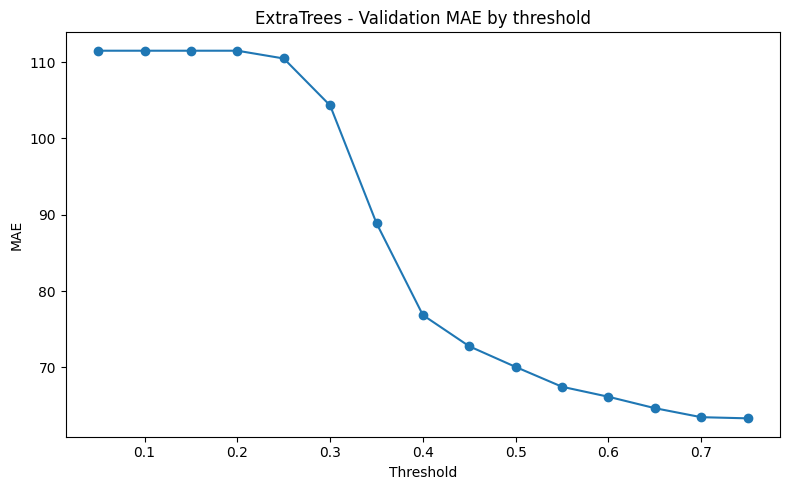

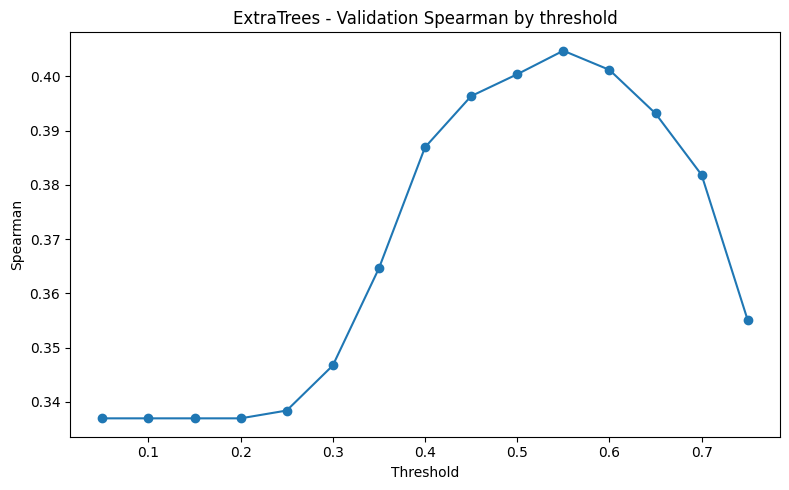

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(eval_results["threshold_df"]["threshold"], eval_results["threshold_df"]["MAE"], marker="o")
plt.title("ExtraTrees - Validation MAE by threshold")
plt.xlabel("Threshold")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(eval_results["threshold_df"]["threshold"], eval_results["threshold_df"]["Spearman"], marker="o")
plt.title("ExtraTrees - Validation Spearman by threshold")
plt.xlabel("Threshold")
plt.ylabel("Spearman")
plt.tight_layout()
plt.show()

In [10]:
clf_importance = pd.DataFrame({
    "feature": mymodel.X_train.columns,
    "importance": best_clf.feature_importances_
}).sort_values("importance", ascending=False)

reg_importance = pd.DataFrame({
    "feature": mymodel.X_train.columns,
    "importance": best_reg.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 15 classifier features")
display(clf_importance.head(15))

print("Top 15 regressor features")
display(reg_importance.head(15))

Top 15 classifier features


,feature,importance
16,purchase_frequency,0.179576
10,customer_lifetime_days,0.108887
32,prod_type_3_dominant_share,0.067744
46,top_season_share,0.057779
33,prod_type_3_n_unique,0.044622
21,max_days_between_orders,0.039262
25,top_brand_share,0.038810
36,prod_type_5_dominant_share,0.038511
1,n_sales,0.034544
28,top_color_share,0.032147


Top 15 regressor features


,feature,importance
7,total_revenue_net,0.275821
9,total_revenue_gross,0.065179
37,prod_type_5_n_unique,0.051597
33,prod_type_3_n_unique,0.042942
5,n_items_non_returned,0.041596
29,n_unique_colors,0.033922
71,prod_clasp_n_unique,0.029267
27,n_unique_products,0.027443
6,n_sales_non_returned,0.026905
1,n_sales,0.023491


In [11]:
final_clf = clone(best_clf)
final_reg = clone(best_reg)

final_clf.fit(mymodel.X, mymodel.y_class)

mask_full_buyers = mymodel.y_class == 1
final_reg.fit(
    mymodel.X[mask_full_buyers],
    np.log1p(mymodel.y_reg[mask_full_buyers])
)

print("Full-data retraining done.")
print("Positive buyers used for regressor:", int(mask_full_buyers.sum()))

Full-data retraining done.
Positive buyers used for regressor: 42658


In [12]:
# Predict on test set

X_test = mymodel.prepare_test_data()

proba_test = final_clf.predict_proba(X_test)[:, 1]
reg_test = np.expm1(final_reg.predict(X_test))
reg_test = np.clip(reg_test, 0, None)

pred_test_expected = np.clip(proba_test * reg_test, 0, None)

pred_test_threshold = np.zeros(len(X_test))
mask_pred_buyers_test = proba_test >= eval_results["best_threshold"]
pred_test_threshold[mask_pred_buyers_test] = reg_test[mask_pred_buyers_test]
pred_test_threshold = np.clip(pred_test_threshold, 0, None)

if eval_results["chosen_strategy"] == "expected":
    final_pred_test = pred_test_expected
    submission_name = "submission_extratrees_expected.csv"
else:
    final_pred_test = pred_test_threshold
    submission_name = "submission_extratrees_threshold.csv"

submission = pd.DataFrame({
    "cust_id": mymodel.X_test_full["cust_id"],
    "predicted_revenue_2018_2019": final_pred_test
})

submission.to_csv(submission_name, index=False)

print("Saved:", submission_name)
print("Prediction summary")
print("min :", final_pred_test.min())
print("max :", final_pred_test.max())
print("mean:", final_pred_test.mean())

submission.head()

Completely empty test feature rows: 0
Saved: submission_extratrees_threshold.csv
Prediction summary
min : 0.0
max : 505.5251124566041
mean: 24.12641275393072


,cust_id,predicted_revenue_2018_2019
0,2dfoualegmpt6x2h,345.000464
1,d2q2stjpnzld7a4r,0.000000
2,cojscuqlpylhclv2,0.000000
3,vntezlhi2ryvxk6m,174.701524
4,jgy4ytjkdr2b75wf,175.069736


In [13]:
experiment_summary = pd.DataFrame([{
    "model_family": "ExtraTreesClassifier + ExtraTreesRegressor",
    "best_clf_params": clf_search.best_params_,
    "best_reg_params": reg_search.best_params_,
    "val_auc": eval_results["auc"],
    "val_mae_expected": eval_results["mae_expected"],
    "val_spearman_expected": eval_results["spearman_expected"],
    "best_threshold": eval_results["best_threshold"],
    "best_threshold_mae": eval_results["best_threshold_mae"],
    "best_threshold_spearman": eval_results["best_threshold_spearman"],
    "chosen_strategy": eval_results["chosen_strategy"]
}])

experiment_summary

,model_family,best_clf_params,best_reg_params,val_auc,val_mae_expected,val_spearman_expected,best_threshold,best_threshold_mae,best_threshold_spearman,chosen_strategy
0,ExtraTreesClassifier + ExtraTreesRegressor,"{'n_estimators': 600, 'min_samples_split': 10,...","{'n_estimators': 600, 'min_samples_split': 10,...",0.716813,76.760479,0.385864,0.75,63.328603,0.355056,threshold
